# NOTEBOOK 1 - EDA


In [1]:
import sys
from pathlib import Path

# Make the telco_churn package importable (project root is one level up)
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

np.random.seed(42)
random.seed(42)

%matplotlib inline
sns.set_theme(style='whitegrid', context='talk')

# Output directories
FIGURES_DIR = Path('..') / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Data

Load the CSV exactly as Kaggle ships it — no modifications yet.

In [2]:
DATA_PATH = Path('..') / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head()

Shape: (7043, 21)  →  7,043 rows  ×  21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Quality Check

Before any analysis, find:
- Missing values (explicit NaN)
- Hidden blanks (columns that *look* numeric but aren't)
- Duplicate rows

In [5]:
print('=== Null counts ===')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

=== Null counts ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


In [6]:
# TotalCharges looks numeric but pandas reads it as object
print(f'TotalCharges dtype: {df["TotalCharges"].dtype}')

# Find the problematic rows — they contain a blank space ' ' instead of a number
bad_rows = df[df['TotalCharges'].str.strip() == '']
print(f'\nRows with blank TotalCharges: {len(bad_rows)}')
bad_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

TotalCharges dtype: str

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [7]:
# These 11 rows are brand-new customers (tenure = 0) who have no TotalCharges yet.
# This is not truly 'missing' data — it's a data entry artefact.
# Decision: coerce to numeric (blanks become NaN) then drop those 11 rows.
print(f'Rows with tenure == 0: {(df["tenure"] == 0).sum()}')
print(f'Of those, TotalCharges is blank: {len(bad_rows)}')

# Calculate percentage dynamically against the total number of rows in the dataset
bad_row_percentage = (len(bad_rows) / len(df)) * 100

print(f'\nDropping {len(bad_rows)} rows is {bad_row_percentage:.2f}% of the data — safe to discard.')

Rows with tenure == 0: 11
Of those, TotalCharges is blank: 11

Dropping 11 rows is 0.16% of the data — safe to discard.


## 3. Target Distribution

The target column is `Churn` (Yes / No). We need to understand the class balance before choosing metrics and handling strategies.

In [8]:
churn_counts = df['Churn'].value_counts()
#convert to percentage 
churn_pct = df['Churn'].value_counts(normalize=True) * 100 


print('=== Target class distribution ===')
for label in ['No', 'Yes']:
    print(f'  Churn={label!r}: {churn_counts[label]:,}  ({churn_pct[label]:.1f}%)')

=== Target class distribution ===
  Churn='No': 5,174  (73.5%)
  Churn='Yes': 1,869  (26.5%)


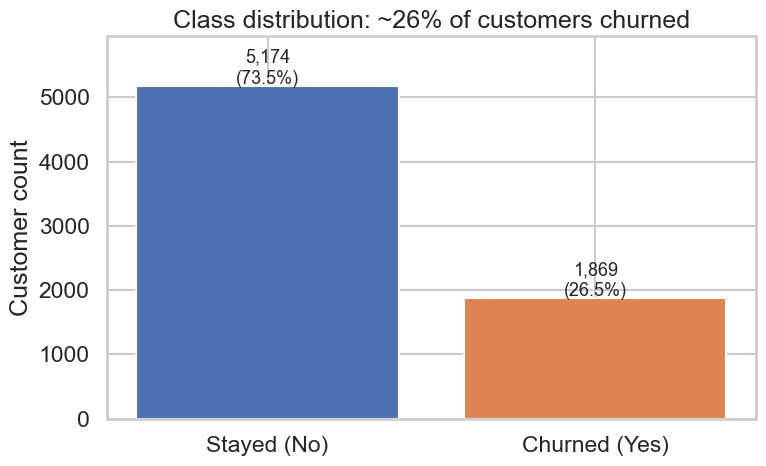


Key insight: moderate imbalance → plain accuracy will be misleading.
We will use ROC-AUC as the primary metric and class_weight="balanced" in models.


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Stayed (No)', 'Churned (Yes)']
values = [churn_counts['No'], churn_counts['Yes']]
bars = ax.bar(labels, values, color=['#4C72B0', '#DD8452'])

for bar, v in zip(bars, values):
    pct = 100 * v / sum(values)
    ax.text(bar.get_x() + bar.get_width() / 2, v + 40,
            f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=13)
# Add headroom
ax.set_ylim(0, max(values) * 1.15)

ax.set_ylabel('Customer count')
ax.set_title('Class distribution: ~26% of customers churned')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nKey insight: moderate imbalance → plain accuracy will be misleading.\nWe will use ROC-AUC as the primary metric and class_weight="balanced" in models.')

## 4. Numerical Feature Distributions

The three numerical features are `tenure`, `MonthlyCharges`, and `TotalCharges`.  
We plot their histograms split by churn status to spot separation.

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Coerce TotalCharges for this analysis
df_num = df.copy()
df_num['TotalCharges'] = pd.to_numeric(df_num['TotalCharges'], errors='coerce')

print('=== Stats by Churn status ===')
for col in num_cols:
    print(f'\n{col}:')
    print(df_num.groupby('Churn')[col].describe().round(2))

=== Stats by Churn status ===

tenure:
        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0

MonthlyCharges:
        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35

TotalCharges:
        count     mean      std    min     25%      50%      75%      max
Churn                                                                    
No     5163.0  2555.34  2329.46  18.80  577.83  1683.60  4264.12  8672.45
Yes    1869.0  1531.80  1890.82  18.85  134.50   703.55  2331.30  8684.80


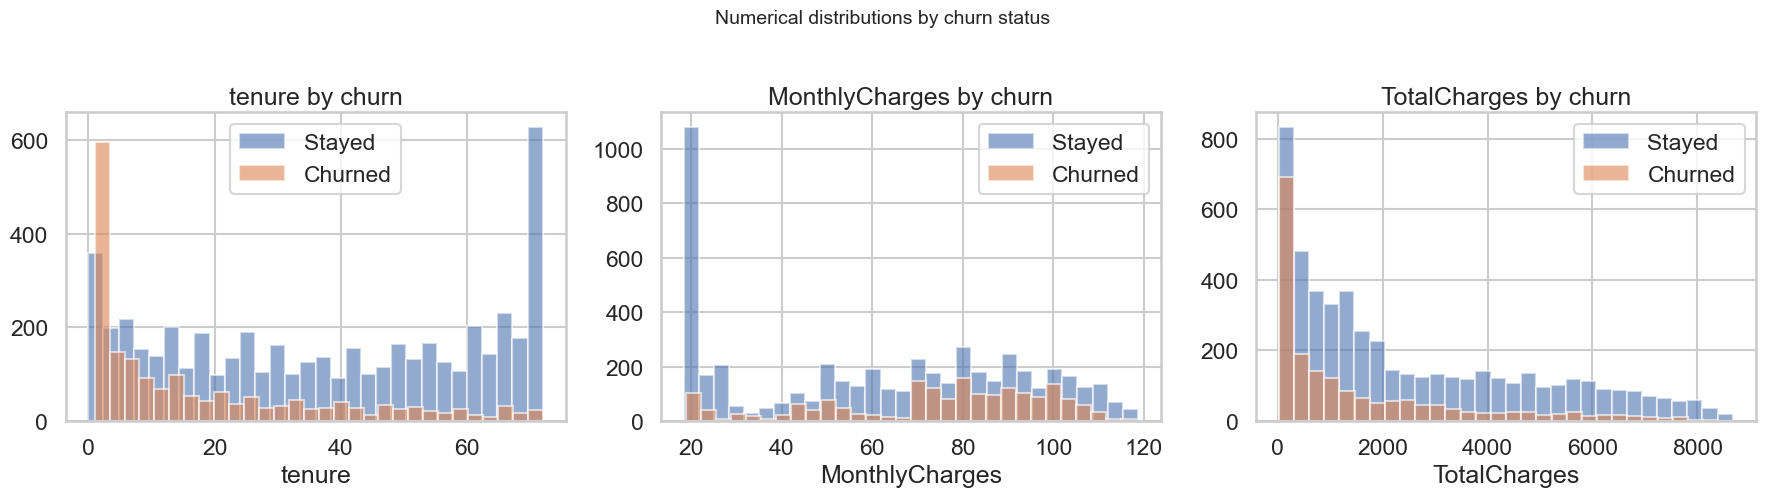

Observations:
  tenure        — Customers who leave usually leave early in their relationship (first ~12 months is high-risk).
  MonthlyCharges— churners skew toward higher bills (Customers paying higher monthly bills are more likely to churn).
  TotalCharges  — churners skew low (Many churners are new customers, so they have not spent much yet).


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    for churn_val, label, color in [('No', 'Stayed', '#4C72B0'), ('Yes', 'Churned', '#DD8452')]:
        subset = df_num.loc[df_num['Churn'] == churn_val, col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color)
    ax.set_title(f'{col} by churn')
    ax.set_xlabel(col)
    ax.legend()

fig.suptitle('Numerical distributions by churn status', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('Observations:')
print('  tenure        — Customers who leave usually leave early in their relationship (first ~12 months is high-risk).')
print('  MonthlyCharges— churners skew toward higher bills (Customers paying higher monthly bills are more likely to churn).')
print('  TotalCharges  — churners skew low (Many churners are new customers, so they have not spent much yet).')

## 5. Categorical Features vs Churn

For each high-signal categorical, compute the churn rate per category. A large spread across categories = strong predictor.

In [12]:
# Contract type — the single strongest driver
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print('Churn rate by Contract type (%):')
print(contract_churn.round(1).to_string())
print('\n→ Month-to-month: 43%  |  Two year: <3%  — enormous spread')

Churn rate by Contract type (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

→ Month-to-month: 43%  |  Two year: <3%  — enormous spread


In [13]:
# Internet service — fiber optic customers pay more yet churn more
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print('Churn rate by InternetService (%):')
print(internet_churn.round(1).to_string())
print('\n→ Fiber optic at 42% vs DSL at 19% — service quality signal')

Churn rate by InternetService (%):
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4

→ Fiber optic at 42% vs DSL at 19% — service quality signal


In [14]:
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print('Churn rate by PaymentMethod (%):')
print(payment_churn.round(1).to_string())
print('\n→ Electronic check customers churn at ~45% — suggest auto-pay migration')

Churn rate by PaymentMethod (%):
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2

→ Electronic check customers churn at ~45% — suggest auto-pay migration


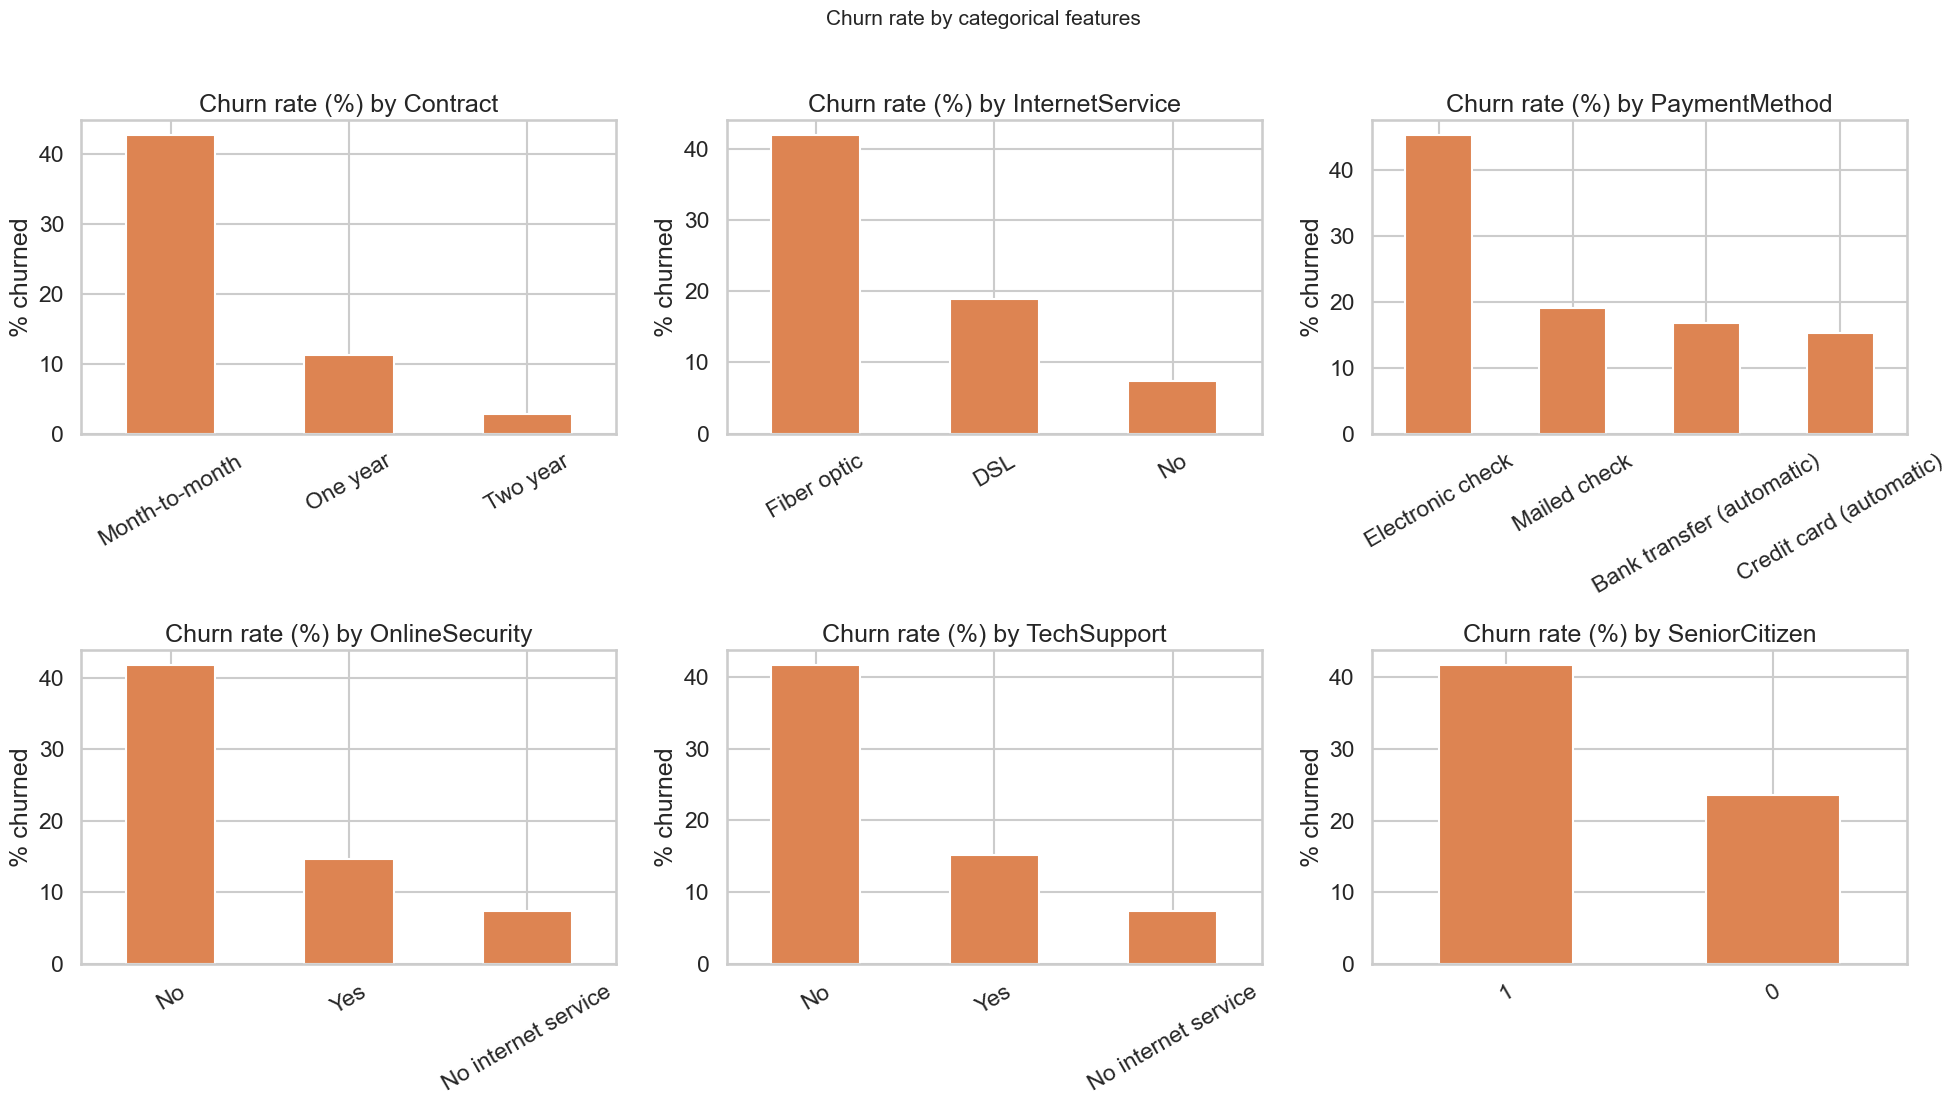

In [15]:
# Combined 2×3 subplot for the six most actionable categoricals
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#DD8452')
    ax.set_title(f'Churn rate (%) by {col}')
    ax.set_ylabel('% churned')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Churn rate by categorical features', y=1.01, fontsize=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_categorical_vs_churn.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

Pearson correlations among the numerical features + the binary target (0/1).  
Expected finding: tenure and TotalCharges are highly correlated (longer customers accumulate more spend).

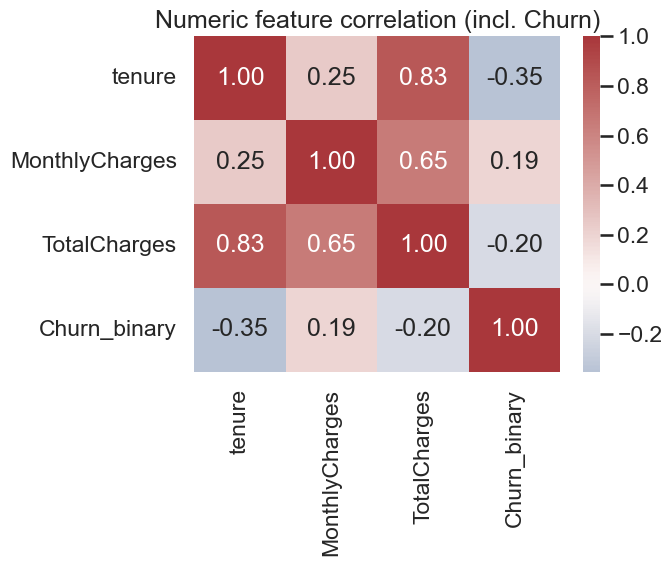

Key correlations:
  tenure ↔ TotalCharges: 0.83  (multicollinearity risk)
  tenure ↔ Churn:        -0.35  (longer tenure = lower churn)
  MonthlyCharges ↔ Churn:0.19  (higher bill = higher churn)


In [16]:
df_corr = df_num.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Numeric feature correlation (incl. Churn)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('Key correlations:')
print(f'  tenure ↔ TotalCharges: {corr.loc["tenure", "TotalCharges"]:.2f}  (multicollinearity risk)')
print(f'  tenure ↔ Churn:        {corr.loc["tenure", "Churn_binary"]:.2f}  (longer tenure = lower churn)')
print(f'  MonthlyCharges ↔ Churn:{corr.loc["MonthlyCharges", "Churn_binary"]:.2f}  (higher bill = higher churn)')

## 7. MonthlyCharges Boxplot

Boxplot makes the price gap between churners and stayers crystal-clear: median, quartiles, and outliers in one view.

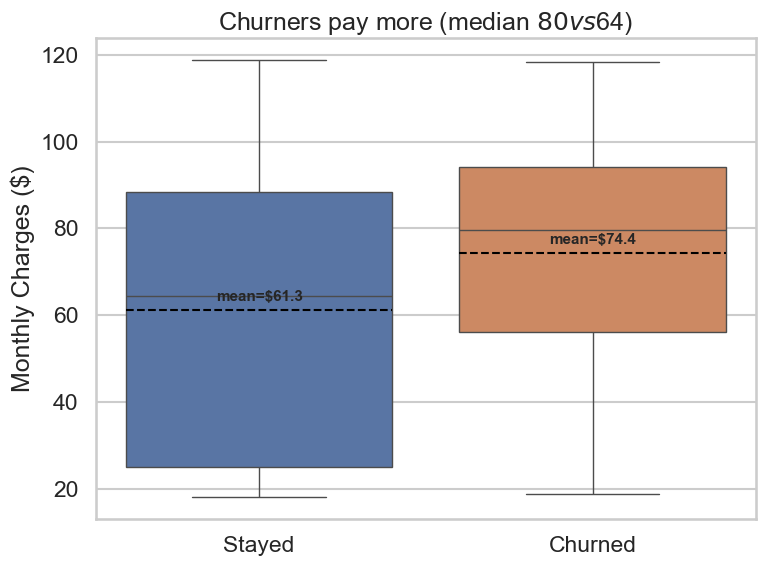

Median MonthlyCharges — Churned: $79.65  |  Stayed: $64.43
Gap: ~15/month


In [17]:
plot_df = df[['Churn', 'MonthlyCharges']].copy()
plot_df['Status'] = plot_df['Churn'].map({'No': 'Stayed', 'Yes': 'Churned'})

medians = plot_df.groupby('Status')['MonthlyCharges'].median()
means   = plot_df.groupby('Status')['MonthlyCharges'].mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=plot_df, x='Status', y='MonthlyCharges',
            hue='Status', order=['Stayed', 'Churned'],
            palette={'Stayed': '#4C72B0', 'Churned': '#DD8452'},
            legend=False, ax=ax)

for i, status in enumerate(['Stayed', 'Churned']):
    m = means[status]
    ax.hlines(m, i - 0.4, i + 0.4, colors='black', linestyles='--', linewidth=1.5)
    ax.text(i, m + 2, f'mean=${m:.1f}', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('')
ax.set_ylabel('Monthly Charges ($)')
ax.set_title(f'Churners pay more (median ${medians["Churned"]:.0f} vs ${medians["Stayed"]:.0f})')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04a_monthly_charges_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Median MonthlyCharges — Churned: ${medians["Churned"]:.2f}  |  Stayed: ${medians["Stayed"]:.2f}')
print(f'Gap: ~{medians["Churned"] - medians["Stayed"]:.0f}/month')

## 8. Fairness / Subgroup Analysis

A responsible-AI check: look at churn rates for protected attributes. We are not enforcing any fairness constraint in modelling, but we surface these numbers so the retention team can be aware.

In [18]:
for col in ['gender', 'SeniorCitizen']:
    rates = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    print(f'Churn rate by {col}:')
    for level, rate in rates.items():
        print(f'  {col}={level!r:>10}  →  {rate:.1f}%')
    print()

Churn rate by gender:
  gender=  'Female'  →  26.9%
  gender=    'Male'  →  26.2%

Churn rate by SeniorCitizen:
  SeniorCitizen=         0  →  23.6%
  SeniorCitizen=         1  →  41.7%



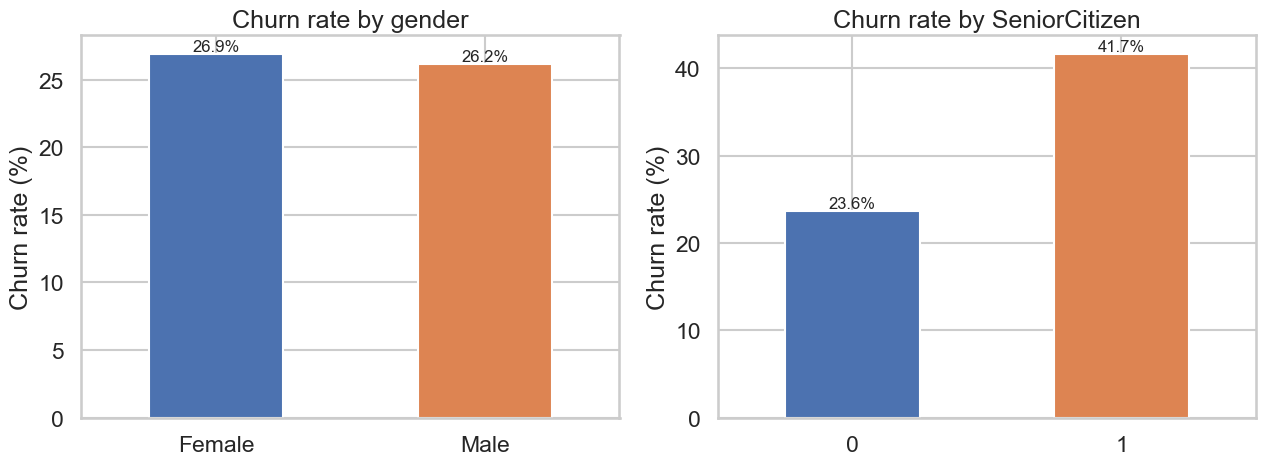

Fairness note: Senior citizens churn at ~42% vs ~24% for non-seniors.
The retention team should ensure campaigns reach senior customers equally.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['gender', 'SeniorCitizen']):
    rates = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    rates.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04b_churn_rate_by_gender_senior.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fairness note: Senior citizens churn at ~42% vs ~24% for non-seniors.')
print('The retention team should ensure campaigns reach senior customers equally.')

## 9. Tenure Cohort Analysis

Group customers into tenure buckets (0-12 months, 1-2 years, etc.) to see which cohort has the highest churn risk.

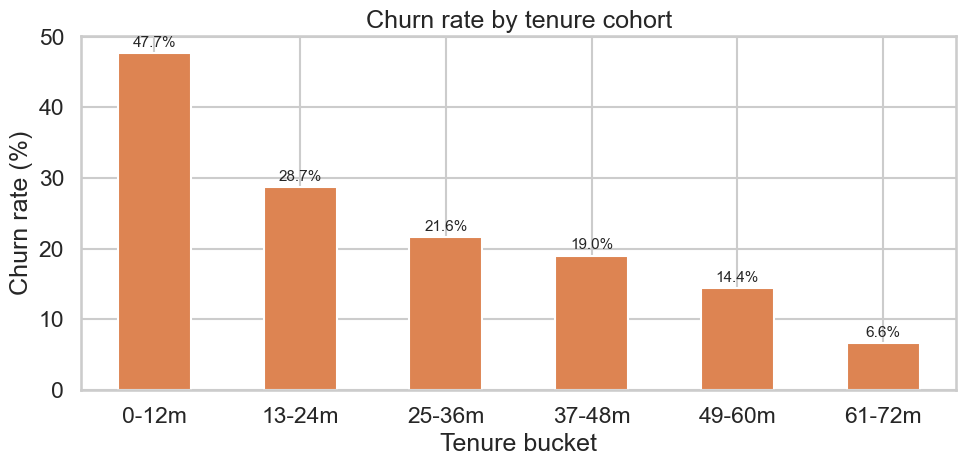


Insight: First 12 months is the highest-risk window.
After 2 years, churn rate drops dramatically.


In [20]:
df_t = df.copy()
df_t['TotalCharges'] = pd.to_numeric(df_t['TotalCharges'], errors='coerce')
df_t['tenure_bucket'] = pd.cut(
    df_t['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m'],
    right=True
)

cohort_churn = df_t.groupby('tenure_bucket', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
cohort_churn.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_title('Churn rate by tenure cohort')
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('Tenure bucket')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04c_churn_rate_by_tenure_cohort.png', dpi=120, bbox_inches='tight')

plt.show()
print('\nInsight: First 12 months is the highest-risk window.')
print('After 2 years, churn rate drops dramatically.')

## 10. EDA Summary — Key Takeaways

| Finding | Implication |
|---------|-------------|
| ~26% churn rate (moderate imbalance) | Use ROC-AUC as primary metric; apply `class_weight='balanced'` |
| Month-to-month contract → 43% churn | Strongest single predictor; push long-term contracts |
| Fiber optic + high MonthlyCharges → high churn | Service quality issue; not just price |
| Tenure < 12 months → highest risk cohort | Invest in onboarding in the first 90 days |
| Electronic check payment → 45% churn | Migrate to auto-pay with a bill credit |
| Senior citizens churn at 42% vs 24% | Fairness flag for retention campaigns |
| tenure ↔ TotalCharges correlation = 0.83 | Potential multicollinearity; Standard Scaler handles this |

**Next:** [02_data_cleaning_preprocessing.ipynb](02_data_cleaning_preprocessing.ipynb)